<center>
    <h1>Faculty of Information and Communication Technology</h1>
    <h1>Mahidol University</h1>
    <h2>ITCS159 Software Lab for Basic Scientific Problem Solving</h2>
    <h2>Quiz</h2>
</center>

<h4>Direction: This is an Open book examination. Please give the comments for all lines of code to show your understanding. Without the comments, the quiz will not be scored.</h4>

## Print your ID, your name, and section using Python here, e.g., 
## 6088159 Harry Potter Section: 1

6388003 Phuriwat Angkoondittaphong Section: 1

<h2>Import all necessary packages in the below cell</h2>

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io, filters
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn import model_selection

<h2>Q1. Given the information of Wine (<a href='https://www.kaggle.com/brynja/wineuci'>Ref</a>) as presented in a file named <i>Wine.csv</i>. Please answer the following questions.</h2>

<h3>Q1.1. Show the first 10 data (1 point)</h3>

In [4]:
df = pd.read_csv("Wine.csv")
df.head(10)

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
5,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
6,1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
7,1,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
8,1,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045
9,1,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045


<h3>Q1.2. Please use python to check and show whether there is any colum has null value (1 point)</h3>

In [5]:
df.isnull().any()

Class                           False
Alcohol                         False
Malic acid                      False
Ash                             False
Alcalinity of ash               False
Magnesium                       False
Total phenols                   False
Flavanoids                      False
Nonflavanoid phenols            False
Proanthocyanins                 False
Color intensity                 False
Hue                             False
OD280/OD315 of diluted wines    False
Proline                         False
dtype: bool

<h3>Q1.3. Please use Python to show statistics of this dataset in term of count, mean, max, min, and percentile (1 point)</h3>

In [6]:
df.describe()

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


<h3>Q1.4. Using <i>Matplotlib</i> library to display the following output (2 points)</h3>
<img src="Q14_output.png" />

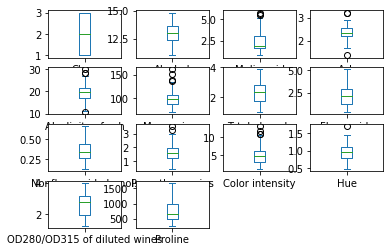

In [11]:
df.plot ( kind ='box', subplots =True , layout =(4, 4) , sharex =False , sharey = False );

<h3>Q1.5. You need to seperate the data in <i>ds</i> loaded in Q1.1 into 2 groups; Training and Testing, where test size is 0.2 and random seed is 5. Then, applying <i>K-nearest Neighbors techniques</i> classification technique from <i>sklearn</i> library to create a predictive model, where <i>n</i> is number of neighbors, using the training set. Note that <i>n</i> is the last digit of your student id. All atributes are considered as inputs. Then, using a prediction model to predict the class of wine in the testing set. (3 points)</h3>

In [30]:
X = df.values[:, 1:]
Y = df.values[:, 0]
X_train, X_test, Y_train, Y_test = model_selection.train_test_split (X, Y, test_size = 0.2, random_state = 5)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, Y_train)

KNeighborsClassifier(n_neighbors=3)

<h3>Q1.6. Write a python code to show the score of the predictive model. (1 point)</h3>

In [31]:
knn.score(X_test, Y_test)

0.6944444444444444

<h3>Q1.7. Write a python code to show the confusion matrix. (1 point)</h3>

In [43]:
pd.DataFrame([pd.DataFrame(knn.predict(X_test)).value_counts().values, Y_test])
# sns.heatmap()

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,15.0,11.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,2.0,1.0,1.0,3.0,3.0,1.0,1.0,2.0,1.0,...,1.0,3.0,3.0,1.0,2.0,2.0,1.0,1.0,3.0,3.0


<h2>Q2. Given a check RGB image. Use your python knowledge to answer the following sub-questions.</h2>
<img src="check.png" />

<h3>Q2.1 Please use Python to display the image. (2 points)</h3>

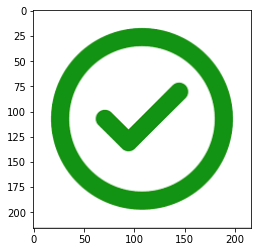

In [15]:
img = io. imread ('check.png')
plt.imshow(img)

<h3>Q2.2 Write a python code to display the image as the following output? (1 point)</h3>
<img src="Q22_output.png"/>

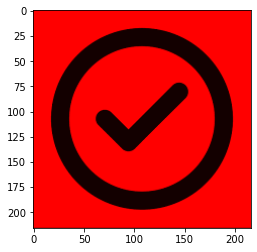

In [20]:
red_check = img.copy()
red_check[..., 1] = 0
red_check[..., 2] = 0
plt.imshow(red_check)

<h3>Q2.3 Write a python code to blur the image with sigma = <i>n</i> degrees, where <i>n</i> is the last digit of your student id and display the output? (1 points)</h3>

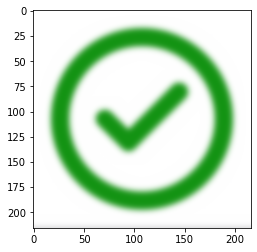

In [22]:
# my id is 6388003 -> sigma = 3
blurred_img = filters . gaussian (img , sigma=3 , multichannel=True )
plt. imshow ( blurred_img )

<h2>Q3. Given the following data about Beijing PM2.5 Data (PRSA_data_2010.1.1-2014.12.31.csv) [1] (<a href='https://archive.ics.uci.edu/ml/datasets/Beijing+PM2.5+Data'>Ref</a>). Please answer the following question</h2>

<h3>Data Set Information:</h3>
The data time period is between Jan 1st, 2010 to Dec 31st, 2014. The missing data is denoted by NA.

<h3>Attribute Information:</h3>
<ol>
    <li>No: row number</li>
    <li>year: year of data in this row</li>
    <li>month: month of data in this row</li>
    <li>day: day of data in this row</li>
    <li>hour: hour of data in this row</li>
    <li>pm2.5: PM2.5 concentration (ug/m^3)</li>
    <li>DEWP: Dew Point (â„ƒ)</li>
    <li>TEMP: Temperature (â„ƒ)</li>
    <li>PRES: Pressure (hPa)</li>
    <li>cbwd: Combined wind direction</li>
    <li>Iws: Cumulated wind speed (m/s)</li>
    <li>Is: Cumulated hours of snow</li>
    <li>Ir: Cumulated hours of rain</li>
</ol>

<h3>Reference</h3>
<ol>
    <li>Liang, X., Zou, T., Guo, B., Li, S., Zhang, H., Zhang, S., Huang, H. and Chen, S. X. (2015). Assessing Beijing's PM2.5 pollution: severity, weather impact, APEC and winter heating. Proceedings of the Royal Society A, 471, 20150257.</li>
</ol>


<h3>Q3.1 Show the first five rows of the data as shown below. (2 points)</h3>
<img src='Q31_output.png'/>

In [23]:
df2 = pd.read_csv("PRSA_data_2010.1.1-2014.12.31.csv")
df2.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


<h3>Q3.2 Find the correlation of this data and the following questions</h3>

<h4>Q3.2.1 Find the correlation and show the heatmap (2 point)</h4>

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
Class,1.000000,-0.328222,0.437776,-0.049643,0.517859,-0.209179,-0.719163,-0.847498,0.489109,-0.499130,0.265668,-0.617369,-0.788230,-0.633717
Alcohol,-0.328222,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
Malic acid,0.437776,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
Ash,-0.049643,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
Alcalinity of ash,0.517859,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
Magnesium,-0.209179,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
Total phenols,-0.719163,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
Flavanoids,-0.847498,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
Nonflavanoid phenols,0.489109,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
Proanthocyanins,-0.499130,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417


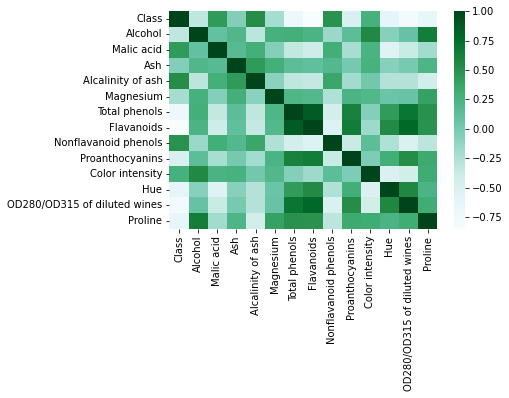

In [25]:
corr = df.corr()
sns.heatmap(corr,xticklabels=corr.columns.values,yticklabels=corr.columns.values,cmap="BuGn")
corr

<h4>Q3.2.2 Which pair of variables has the strongest positive correlation, and what does it mean? (2 points)</h4>

the pair Flavanoids and Total phenols has a score of 0.864564

meaning these two parameters tends to go along with each other

one parameter goes up other one goes up as well and vice versa